# Notebook 11 — Test Set Inference

> **No training required** — loads `best_model.pth` and runs inference on the held-out test set.

---

## Objectives

- Load the trained SegResNet checkpoint
- Run sliding window inference on all test patients
- Apply postprocessing (argmax + label restoration 3 → 4)
- Save predictions as `.nii.gz` files (BraTS submission format)
- Visualize predictions for a sample of test patients
- Save a summary CSV with tumor volume estimates per patient

## Pipeline

```
Test .pt files
      ↓
SegResNet (best_model.pth)
      ↓
SlidingWindowInferer (128³, overlap=0.5)
      ↓
Argmax → class indices [0,1,2,3]
      ↓
Label restore: 3 → 4  (BraTS format)
      ↓
Save as .nii.gz  +  Volume CSV  +  Visualization
```

## 1. Setup

### 1.1 Install Dependencies

In [1]:
!pip -q install monai nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.

### 1.2 Imports

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nibabel as nib

import torch
from torch.utils.data import Dataset, DataLoader

from monai.networks.nets import SegResNet
from monai.inferers import SlidingWindowInferer
from monai.transforms import Activations, AsDiscrete, Compose

2026-06-30 11:10:39.611024: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782817840.002327      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782817840.118556      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782817841.065963      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782817841.066007      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782817841.066011      23 computation_placer.cc:177] computation placer alr

### 1.3 Paths & Constants

In [3]:
PROCESSED_PATH = Path(
    "/kaggle/input/datasets/mariammohamed1095/workingg/datasets/processed/cv"
)

CHECKPOINT_PATH = Path(
    "/kaggle/input/models/mariammohamed1095/brats2020-segresnet/pytorch/default/1/models/segmentation/best_model.pth"
)

PREDICTION_DIR = Path("/kaggle/working/predictions")
FIGURE_DIR     = Path("/kaggle/working/reports/figures")
RESULT_DIR     = Path("/kaggle/working/reports/results")

PREDICTION_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

ROI_SIZE      = (128, 128, 128)
SW_BATCH_SIZE = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device         :", device)
print("Checkpoint     :", CHECKPOINT_PATH)
print("Prediction dir :", PREDICTION_DIR)

Device         : cuda
Checkpoint     : /kaggle/input/models/mariammohamed1095/brats2020-segresnet/pytorch/default/1/models/segmentation/best_model.pth
Prediction dir : /kaggle/working/predictions


## 2. Load Model

### 2.1 Build and Load SegResNet

In [4]:
model = SegResNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    init_filters=32,
    blocks_down=(1, 2, 2, 4),
    blocks_up=(1, 1, 1),
    dropout_prob=0.2,
).to(device)

# Checkpoint is a raw state dict (saved with torch.save(model.state_dict(), path))
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint)
model.eval()

print("Checkpoint loaded successfully.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Checkpoint loaded successfully.
Parameters: 18,798,660


### 2.2 Inferer and Post-processing

In [5]:
inferer = SlidingWindowInferer(
    roi_size=ROI_SIZE,
    sw_batch_size=SW_BATCH_SIZE,
    overlap=0.5,
    mode="gaussian",
)

post_pred = Compose([
    Activations(softmax=True),
    AsDiscrete(argmax=True),
])

print("Inferer  :", inferer.__class__.__name__)
print("ROI size :", ROI_SIZE)

Inferer  : SlidingWindowInferer
ROI size : (128, 128, 128)


## 3. Test Dataset

### 3.1 TestDataset

Test patients have no ground-truth labels — only the `image` tensor is loaded.
`metadata` carries the original affine matrix needed to save predictions as NIfTI.

In [6]:
class TestDataset(Dataset):
    """
    Dataset for test-set .pt files (no label key).

    Each .pt file contains:
        image      : Tensor (4, D, H, W)  float32
        metadata   : dict  (includes original affine)
        patient_id : str
    """

    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.files    = sorted(self.root_dir.glob("*.pt"))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        sample = torch.load(self.files[index], weights_only=False)
        return {
            "image":      sample["image"],
            "metadata":   sample["metadata"],
            "patient_id": sample["patient_id"],
        }


test_dataset = TestDataset(PROCESSED_PATH / "test")
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

print("Test patients:", len(test_dataset))

Test patients: 56


### 3.2 Inspect One Test Sample

In [7]:
sample = test_dataset[0]

print("Keys       :", list(sample.keys()))
print("Image      :", sample["image"].shape)
print("Patient ID :", sample["patient_id"])
print("Metadata   :", list(sample["metadata"].keys()))

Keys       : ['image', 'metadata', 'patient_id']
Image      : torch.Size([4, 103, 120, 93])
Patient ID : BraTS20_Training_001
Metadata   : ['affine', 'original_affine', 'spatial_shape', 'foreground_start_coord', 'foreground_end_coord']


## 4. Inference Loop

### 4.1 Helper — Save Prediction as NIfTI

Saves the prediction mask in BraTS submission format:
- Label 3 (ET) remapped back to label 4 (original BraTS convention)
- Saved as `.nii.gz` with the original patient affine matrix

In [8]:
def save_prediction_nifti(
    prediction: np.ndarray,
    metadata:   dict,
    patient_id: str,
    output_dir: Path,
) -> Path:
    """
    Save a segmentation prediction as NIfTI (.nii.gz).

    Remaps label 3 → 4 to restore the original BraTS convention
    before saving.

    Parameters
    ----------
    prediction : np.ndarray  shape (D, H, W)  integer class indices [0,1,2,3]
    metadata   : dict        must contain "affine" key (4x4 numpy array)
    patient_id : str
    output_dir : Path

    Returns
    -------
    Path  to the saved file
    """
    pred_brats = prediction.copy()
    pred_brats[prediction == 3] = 4

    affine = np.array(metadata.get("affine", np.eye(4)))
    nifti  = nib.Nifti1Image(pred_brats.astype(np.int16), affine)

    out_path = output_dir / f"{patient_id}_seg.nii.gz"
    nib.save(nifti, out_path)

    return out_path

### 4.2 Run Inference on All Test Patients

In [9]:
records = []

with torch.no_grad():

    for i, batch in enumerate(test_loader):

        patient_id = batch["patient_id"][0]
        image      = batch["image"].to(device)   # (1, 4, D, H, W)
        metadata   = {k: v[0] if isinstance(v, (list, torch.Tensor)) else v
                      for k, v in batch["metadata"].items()}

        logits  = inferer(image, model)            # (1, 4, D, H, W)
        pred    = post_pred(logits[0]).squeeze()   # (D, H, W)
        pred_np = pred.cpu().numpy().astype(np.int16)

        out_path = save_prediction_nifti(pred_np, metadata, patient_id, PREDICTION_DIR)

        wt_vol = int((pred_np > 0).sum())
        tc_vol = int(((pred_np == 1) | (pred_np == 3)).sum())
        et_vol = int((pred_np == 3).sum())

        records.append({
            "patient_id":   patient_id,
            "wt_volume":    wt_vol,
            "tc_volume":    tc_vol,
            "et_volume":    et_vol,
            "total_voxels": int(pred_np.size),
            "wt_fraction":  round(wt_vol / pred_np.size, 5),
            "saved_to":     str(out_path),
        })

        if (i + 1) % 5 == 0 or (i + 1) == len(test_loader):
            print(f"  [{i+1:02d}/{len(test_loader)}] {patient_id} "
                  f"| WT {wt_vol:6d}  TC {tc_vol:6d}  ET {et_vol:6d} voxels")

print(f"\nDone. {len(records)} predictions saved to {PREDICTION_DIR}")

/tmp/ipykernel_23/2070036745.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  affine = np.array(metadata.get("affine", np.eye(4)))


  [05/56] BraTS20_Training_023 | WT  42358  TC  16875  ET  11380 voxels
  [10/56] BraTS20_Training_043 | WT  34925  TC   7078  ET   3609 voxels
  [15/56] BraTS20_Training_064 | WT 103794  TC  71138  ET  33710 voxels
  [20/56] BraTS20_Training_109 | WT  94727  TC  31275  ET  24961 voxels
  [25/56] BraTS20_Training_127 | WT  41016  TC   5962  ET   5670 voxels
  [30/56] BraTS20_Training_156 | WT 118442  TC  44546  ET  27968 voxels
  [35/56] BraTS20_Training_219 | WT  62532  TC  25384  ET  15957 voxels
  [40/56] BraTS20_Training_238 | WT 156286  TC 125151  ET 123184 voxels
  [45/56] BraTS20_Training_279 | WT 153247  TC 116513  ET   4178 voxels
  [50/56] BraTS20_Training_327 | WT 183462  TC 111148  ET   8340 voxels
  [55/56] BraTS20_Training_357 | WT  71512  TC  33965  ET  14864 voxels
  [56/56] BraTS20_Training_366 | WT  46089  TC  22900  ET  18008 voxels

Done. 56 predictions saved to /kaggle/working/predictions


## 5. Tumor Volume Summary

### 5.1 Results Table

In [10]:
volume_df = pd.DataFrame(records)
volume_df.to_csv(RESULT_DIR / "test_predictions_summary.csv", index=False)

display_cols = ["patient_id", "wt_volume", "tc_volume", "et_volume", "wt_fraction"]
volume_df[display_cols].head(10)

,patient_id,wt_volume,tc_volume,et_volume,wt_fraction
0,BraTS20_Training_001,183736,46121,30982,0.15984
1,BraTS20_Training_006,130436,44560,33994,0.16612
2,BraTS20_Training_010,29190,6911,6472,0.07874
3,BraTS20_Training_016,143053,33258,31494,0.21858
4,BraTS20_Training_023,42358,16875,11380,0.06918
5,BraTS20_Training_026,176812,35782,27428,0.21783
6,BraTS20_Training_031,84858,28594,20955,0.10653
7,BraTS20_Training_034,92041,44556,25023,0.21893
8,BraTS20_Training_040,156499,46381,26883,0.18213
9,BraTS20_Training_043,34925,7078,3609,0.08003


### 5.2 Volume Statistics

In [11]:
print("Tumor Volume Statistics — Test Set")
print("=" * 45)
for col, label in [("wt_volume","WT"), ("tc_volume","TC"), ("et_volume","ET")]:
    print(f"{label}  mean={volume_df[col].mean():.0f}  "
          f"std={volume_df[col].std():.0f}  "
          f"min={volume_df[col].min()}  "
          f"max={volume_df[col].max()}")

Tumor Volume Statistics — Test Set
WT  mean=101051  std=51747  min=15355  max=196869
TC  mean=42239  std=32890  min=2644  max=131231
ET  mean=21332  std=19754  min=554  max=123184


### 5.3 Volume Distribution Plot

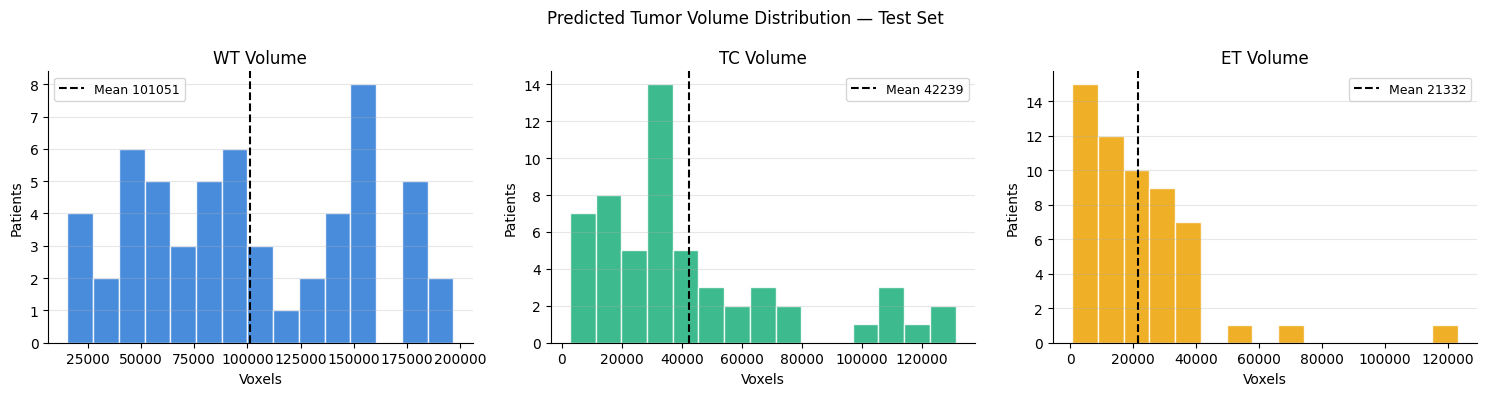

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ("WT Volume", "wt_volume", "#2a78d6"),
    ("TC Volume", "tc_volume", "#1baf7a"),
    ("ET Volume", "et_volume", "#eda100"),
]

for ax, (title, col, color) in zip(axes, pairs):
    ax.hist(volume_df[col], bins=15, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(volume_df[col].mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"Mean {volume_df[col].mean():.0f}")
    ax.set_title(title)
    ax.set_xlabel("Voxels")
    ax.set_ylabel("Patients")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Predicted Tumor Volume Distribution — Test Set", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "test_volume_distribution.png", dpi=150)
plt.show()

## 6. Prediction Visualization

### 6.1 Color Map

| Color | Label | Region |
|-------|-------|--------|
| Red | 1 | NCR/NET — Necrotic Core |
| Green | 2 | ED — Peritumoral Edema |
| Blue | 3 | ET — Enhancing Tumor |

In [13]:
LABEL_COLORS = {
    1: [1.0, 0.2, 0.2],
    2: [0.2, 0.9, 0.3],
    3: [0.2, 0.5, 1.0],
}

def overlay_mask(image_slice, mask_slice, alpha=0.45):
    img = image_slice.copy().astype(float)
    if img.max() > img.min():
        img = (img - img.min()) / (img.max() - img.min())
    rgb = np.stack([img, img, img], axis=-1)
    for label_val, color in LABEL_COLORS.items():
        mask = mask_slice == label_val
        for c in range(3):
            rgb[:, :, c] = np.where(mask,
                rgb[:, :, c] * (1 - alpha) + color[c] * alpha,
                rgb[:, :, c])
    return np.clip(rgb, 0, 1)

### 6.2 Visualize 6 Test Patients

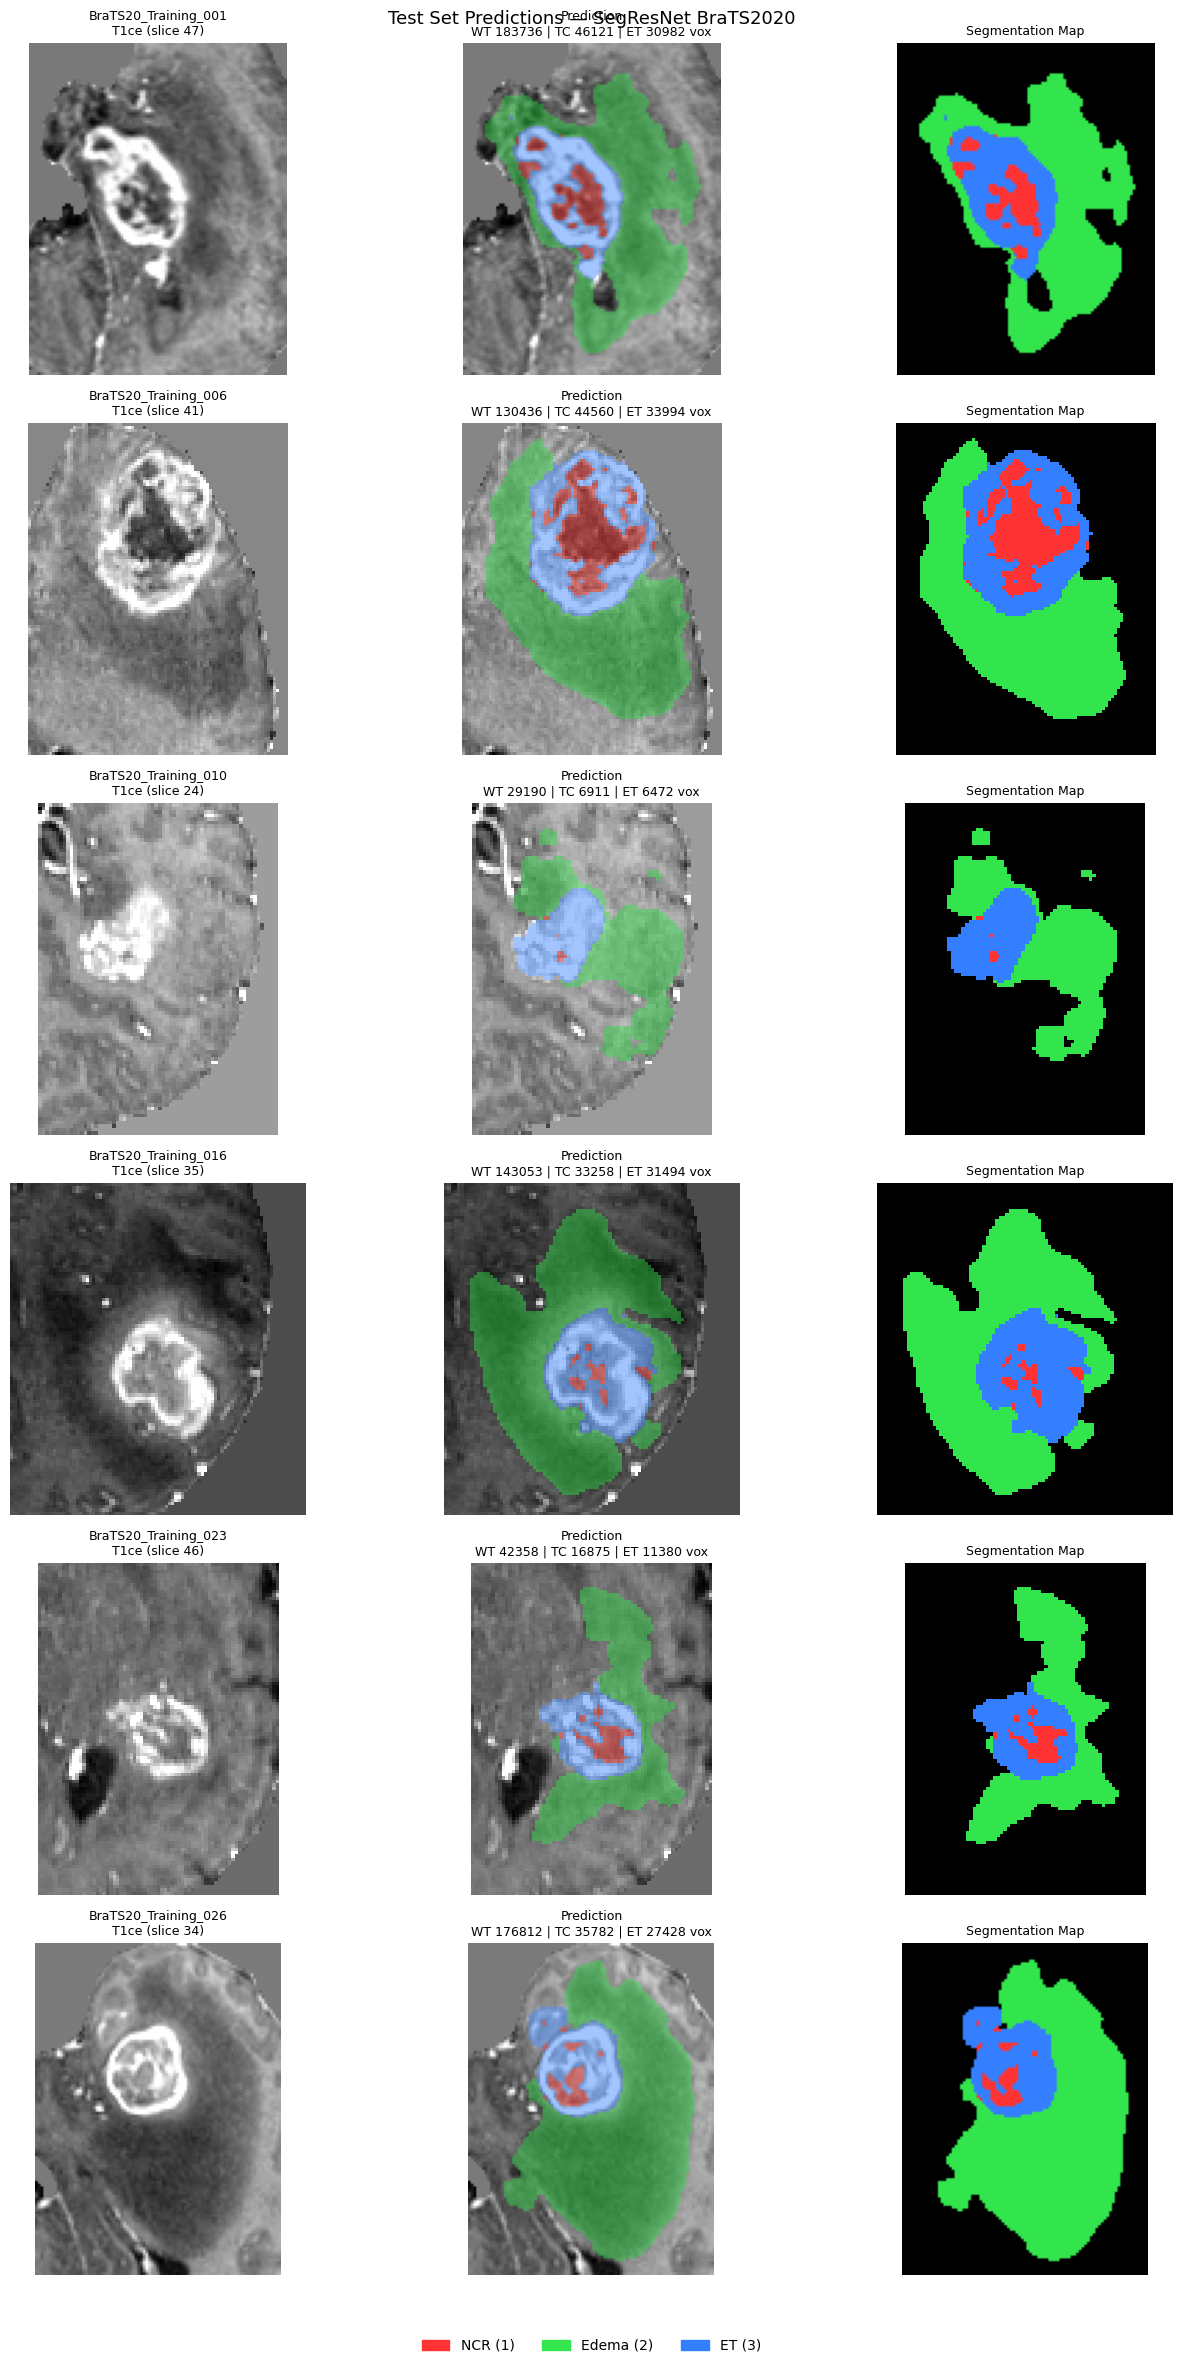

In [14]:
vis_indices = list(range(min(6, len(test_dataset))))

fig, axes = plt.subplots(len(vis_indices), 3, figsize=(14, 4 * len(vis_indices)))
if len(vis_indices) == 1:
    axes = axes[None, :]

with torch.no_grad():

    for row, idx in enumerate(vis_indices):

        sample     = test_dataset[idx]
        patient_id = sample["patient_id"]
        image      = sample["image"].unsqueeze(0).to(device)

        logits  = inferer(image, model)
        pred    = post_pred(logits[0]).squeeze().cpu().numpy().astype(np.int16)

        tumor_per_slice = (pred > 0).sum(axis=(1, 2))
        best_slice = int(tumor_per_slice.argmax()) if tumor_per_slice.max() > 0 else pred.shape[0] // 2

        t1ce_slice = sample["image"][2, best_slice].numpy()
        pred_slice = pred[best_slice]

        wt_vol = int((pred > 0).sum())
        tc_vol = int(((pred == 1) | (pred == 3)).sum())
        et_vol = int((pred == 3).sum())

        axes[row, 0].imshow(t1ce_slice, cmap="gray")
        axes[row, 0].set_title(f"{patient_id}\nT1ce (slice {best_slice})", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(overlay_mask(t1ce_slice, pred_slice))
        axes[row, 1].set_title(f"Prediction\nWT {wt_vol} | TC {tc_vol} | ET {et_vol} vox", fontsize=9)
        axes[row, 1].axis("off")

        class_rgb = np.zeros((*pred_slice.shape, 3))
        for label_val, color in LABEL_COLORS.items():
            mask = pred_slice == label_val
            for c in range(3):
                class_rgb[:, :, c] = np.where(mask, color[c], class_rgb[:, :, c])
        axes[row, 2].imshow(class_rgb)
        axes[row, 2].set_title("Segmentation Map", fontsize=9)
        axes[row, 2].axis("off")

patches = [
    mpatches.Patch(color=[1.0, 0.2, 0.2], label="NCR (1)"),
    mpatches.Patch(color=[0.2, 0.9, 0.3], label="Edema (2)"),
    mpatches.Patch(color=[0.2, 0.5, 1.0], label="ET (3)"),
]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=10, frameon=False)
plt.suptitle("Test Set Predictions — SegResNet BraTS2020", fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(FIGURE_DIR / "test_predictions_visualization.png", dpi=150)
plt.show()

### 6.3 Multi-Slice View — One Patient

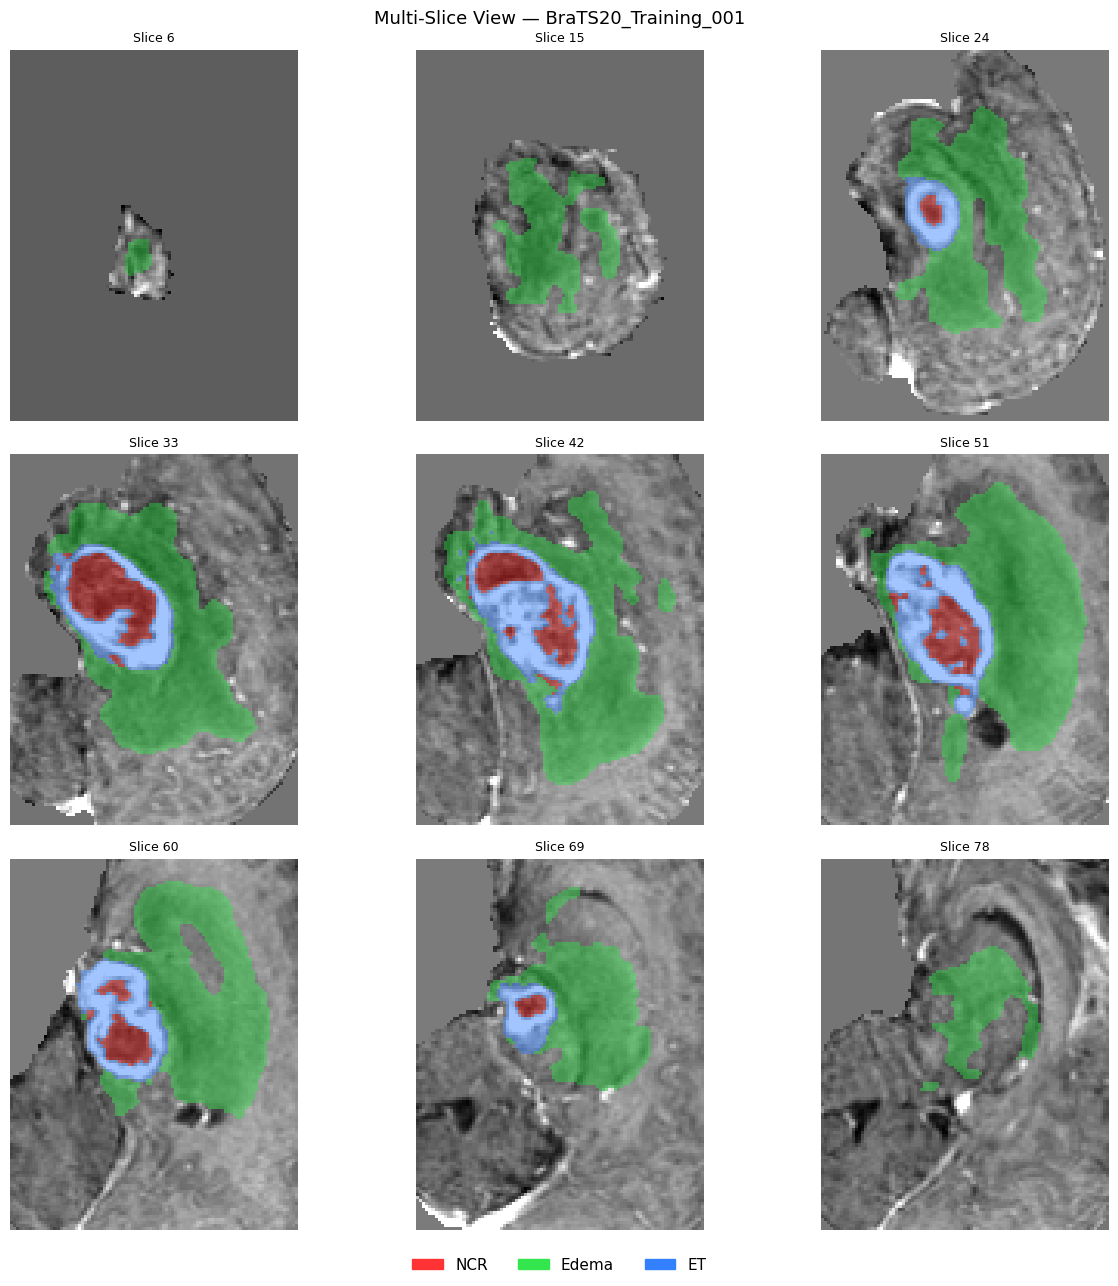

In [15]:
sample     = test_dataset[0]
patient_id = sample["patient_id"]
image_vol  = sample["image"].unsqueeze(0).to(device)

with torch.no_grad():
    logits = inferer(image_vol, model)

pred_vol = post_pred(logits[0]).squeeze().cpu().numpy().astype(np.int16)

tumor_slices = np.where((pred_vol > 0).sum(axis=(1,2)) > 50)[0]

if len(tumor_slices) >= 9:
    step = len(tumor_slices) // 9
    show_slices = tumor_slices[::step][:9]
else:
    show_slices = np.linspace(0, pred_vol.shape[0]-1, 9, dtype=int)

fig, axes = plt.subplots(3, 3, figsize=(13, 13))

for ax, sl in zip(axes.flat, show_slices):
    t1ce = sample["image"][2, sl].numpy()
    pred = pred_vol[sl]
    ax.imshow(overlay_mask(t1ce, pred))
    ax.set_title(f"Slice {sl}", fontsize=9)
    ax.axis("off")

patches = [
    mpatches.Patch(color=[1.0, 0.2, 0.2], label="NCR"),
    mpatches.Patch(color=[0.2, 0.9, 0.3], label="Edema"),
    mpatches.Patch(color=[0.2, 0.5, 1.0], label="ET"),
]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=11, frameon=False)
plt.suptitle(f"Multi-Slice View — {patient_id}", fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(FIGURE_DIR / "test_multislice_view.png", dpi=150)
plt.show()

## 7. Summary

In [16]:
print("=" * 60)
print("Test Set Inference Summary — SegResNet BraTS2020")
print("=" * 60)
print()
print(f"Test patients          : {len(records)}")
print(f"Predictions saved to   : {PREDICTION_DIR}")
print(f"Format                 : NIfTI (.nii.gz), labels [0,1,2,4]")
print()
print(f"Mean WT volume : {volume_df['wt_volume'].mean():.0f} voxels")
print(f"Mean TC volume : {volume_df['tc_volume'].mean():.0f} voxels")
print(f"Mean ET volume : {volume_df['et_volume'].mean():.0f} voxels")
print()
print("Artifacts saved:")
print(f"  {RESULT_DIR / 'test_predictions_summary.csv'}")
print(f"  {FIGURE_DIR / 'test_volume_distribution.png'}")
print(f"  {FIGURE_DIR / 'test_predictions_visualization.png'}")
print(f"  {FIGURE_DIR / 'test_multislice_view.png'}")
print(f"  {PREDICTION_DIR} — {len(records)} .nii.gz files")

Test Set Inference Summary — SegResNet BraTS2020

Test patients          : 56
Predictions saved to   : /kaggle/working/predictions
Format                 : NIfTI (.nii.gz), labels [0,1,2,4]

Mean WT volume : 101051 voxels
Mean TC volume : 42239 voxels
Mean ET volume : 21332 voxels

Artifacts saved:
  /kaggle/working/reports/results/test_predictions_summary.csv
  /kaggle/working/reports/figures/test_volume_distribution.png
  /kaggle/working/reports/figures/test_predictions_visualization.png
  /kaggle/working/reports/figures/test_multislice_view.png
  /kaggle/working/predictions — 56 .nii.gz files
